# Decision Trees — a step-by-step, runnable notebook

A decision tree is the machine-learning version of *20 Questions*: to classify a point it asks a series of simple `feature <= threshold?` questions and walks down the branches to a leaf. It **learns** which questions to ask, in what order, by greedily picking at each step the split that most reduces **impurity** (how mixed the labels are). The result is a model you can read as a flowchart — and the atom that random forests and gradient boosting are built from.

This notebook builds that, one measurement at a time, on **real scikit-learn datasets** (no download): **Iris** (150 flowers) for the from-scratch tree and the boundary, **Breast Cancer** (569 tumours) for overfitting and importance, and **Diabetes** (442 patients) for the regression staircase. It is the executable companion to the chapter and to `decision_trees.py`; every function used here lives in that module, imported so the notebook and the module can never drift apart.

By the end you will have **measured**, not just been told:

1. what **Gini** and **entropy** compute (0 when pure, maximal at 50/50);
2. a real **information-gain** split, by hand and in code (parent − weighted children);
3. a decision tree **grown from scratch** and **verified** to match scikit-learn;
4. the **overfitting curve** — train → 1.0 while validation plateaus — and the sweet-spot depth;
5. why **MDI feature importance is fooled** by a high-cardinality noise column, and permutation is not;
6. a **regression tree** as a piecewise-constant staircase.

Everything runs on CPU in a couple of seconds, seeded for reproducibility.

## Step 0 — Setup and version banner

We import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.tree import DecisionTreeClassifier, plot_tree

from decision_trees import (
    gini, entropy, information_gain, best_split,
    DecisionTreeScratch, verify_against_sklearn,
    load_iris_2d, load_iris_full, load_cancer,
    depth_sweep, feature_importance, regression_staircase,
)

print(f'numpy {np.__version__} | scikit-learn {sklearn.__version__}')
iris2d = load_iris_2d()
print(f'Iris slice: {iris2d.x_train.shape[0]} train + {iris2d.x_test.shape[0]} test flowers, '
      f'features {iris2d.feature_names}, classes {iris2d.class_names}')

numpy 2.4.6 | scikit-learn 1.9.0
Iris slice: 105 train + 45 test flowers, features ['petal length (cm)', 'petal width (cm)'], classes [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


## Step 1 — Impurity: how mixed is a node?

A split is 'good' when it makes the children **purer**. We need a number for 'mixed'. Two standard choices, writing $p_c$ for the fraction of class $c$ in a node:

$$\text{Gini} = 1 - \sum_c p_c^2 \qquad \text{Entropy} = -\sum_c p_c \log_2 p_c$$

Both are **0 when the node is pure** and **maximal at 50/50** (Gini 0.5, entropy 1 bit for two classes). Let's confirm on the most-mixed node (5 vs 5) and a pure node (10 vs 0).

In [2]:
fifty_fifty = np.array([0]*5 + [1]*5)
pure = np.array([0]*10)
print(f'50/50 node : Gini={gini(fifty_fifty):.3f}   entropy={entropy(fifty_fifty):.3f} bits   (MAX impurity)')
print(f'pure  node : Gini={gini(pure):.3f}   entropy={entropy(pure):.3f} bits   (ZERO impurity)')
print('\nSplits try to move nodes from ~0.5 toward 0.')

50/50 node : Gini=0.500   entropy=1.000 bits   (MAX impurity)
pure  node : Gini=0.000   entropy=0.000 bits   (ZERO impurity)

Splits try to move nodes from ~0.5 toward 0.


## Step 2 — Information gain: scoring a split

A split's quality is its **information gain** — the parent's impurity minus the **weighted average** of the children's impurity:

$$\text{Gain} = I(\text{parent}) - \left(\tfrac{n_L}{n} I(\text{left}) + \tfrac{n_R}{n} I(\text{right})\right)$$

The weights stop the tree from 'improving' a node by carving off a tiny pure sliver. Let's reproduce the classic worked example: a parent with **9 'yes' / 5 'no'** split into children **(6 yes, 2 no)** and **(3 yes, 3 no)**.

In [3]:
parent = np.array([1]*6 + [0]*2 + [1]*3 + [0]*3)   # left = first 8, right = last 6
mask   = np.array([True]*8 + [False]*6)
print(f'parent Gini            = {gini(parent):.3f}   (9 yes / 5 no)')
print(f'left child (6/2) Gini  = {gini(parent[mask]):.3f}')
print(f'right child (3/3) Gini = {gini(parent[~mask]):.3f}   (a 50/50 node)')
print(f'information (Gini) gain = {information_gain(parent, mask):.3f}')
print('\nA small positive gain: it purified the left child but left a 50/50 mess on the right.')

parent Gini            = 0.459   (9 yes / 5 no)
left child (6/2) Gini  = 0.375
right child (3/3) Gini = 0.500   (a 50/50 node)
information (Gini) gain = 0.031

A small positive gain: it purified the left child but left a 50/50 mess on the right.


## Step 3 — The greedy best-split search

Growing a tree means, at each node, trying **every feature and every candidate threshold** (the midpoints between adjacent sorted values) and keeping the split with the highest gain. On the Iris petal features, the very first best split is the one that isolates *setosa*.

In [4]:
split = best_split(iris2d.x_train, iris2d.y_train)
print(f'best root split: {iris2d.feature_names[split.feature]} <= {split.threshold:.3f}  '
      f'(Gini gain = {split.gain:.3f})')
left = iris2d.x_train[:, split.feature] <= split.threshold
print(f'left child  ({left.sum():>3} samples): class counts {np.bincount(iris2d.y_train[left])}')
print(f'right child ({(~left).sum():>3} samples): class counts {np.bincount(iris2d.y_train[~left])}')
print('\nThe left child is a PURE setosa leaf already — one question separated a whole class.')

best root split: petal length (cm) <= 2.450  (Gini gain = 0.333)
left child  ( 35 samples): class counts [35]
right child ( 70 samples): class counts [ 0 35 35]

The left child is a PURE setosa leaf already — one question separated a whole class.


## Step 4 — Grow the whole tree from scratch

Apply that split recursively — left, right, left-of-left, ... — until a node is pure, too small, or hits `max_depth`. `DecisionTreeScratch` does exactly this (Gini, greedy binary splits). Here is the learned tree printed as an indented flowchart of `feature <= threshold?` questions.

In [5]:
tree = DecisionTreeScratch(max_depth=3, criterion='gini').fit(iris2d.x_train, iris2d.y_train)
print(tree.describe(iris2d.feature_names, iris2d.class_names))
print(f'\nleaves={tree.n_leaves()}  '
      f'train_acc={tree.score(iris2d.x_train, iris2d.y_train):.3f}  '
      f'test_acc={tree.score(iris2d.x_test, iris2d.y_test):.3f}')

petal length (cm) <= 2.450?  (gini=0.667, n=105)
    ├─ yes: predict 'setosa'  (n=35, gini=0.000)
    └─ no:  petal width (cm) <= 1.550?  (gini=0.500, n=70)
        ├─ yes: petal length (cm) <= 4.950?  (gini=0.057, n=34)
            ├─ yes: predict 'versicolor'  (n=33, gini=0.000)
            └─ no:  predict 'virginica'  (n=1, gini=0.000)
        └─ no:  petal length (cm) <= 4.850?  (gini=0.105, n=36)
            ├─ yes: predict 'versicolor'  (n=2, gini=0.500)
            └─ no:  predict 'virginica'  (n=34, gini=0.057)

leaves=5  train_acc=0.981  test_acc=0.933


## Step 5 — Is it the real thing? Verify against scikit-learn

Grown with the **same criterion (Gini) and the same `max_depth`**, our from-scratch tree should reach the **same test accuracy** as scikit-learn's `DecisionTreeClassifier` and agree with it on the vast majority of predictions. (We don't demand an *exact* match: when two splits tie on gain, CART implementations break the tie by their own rule, so a different-but-equally-good tree is legitimate.)

In [6]:
match = verify_against_sklearn(iris2d, max_depth=3)
print(f'from-scratch test accuracy : {match.scratch_test_acc:.3f}')
print(f'scikit-learn test accuracy : {match.sklearn_test_acc:.3f}')
print(f'they agree on {match.prediction_agreement*100:.1f}% of test predictions')
assert abs(match.scratch_test_acc - match.sklearn_test_acc) < 1e-9
print('\n=> same accuracy, near-total agreement: the growing algorithm is genuine CART.')

from-scratch test accuracy : 0.933
scikit-learn test accuracy : 0.933
they agree on 100.0% of test predictions

=> same accuracy, near-total agreement: the growing algorithm is genuine CART.


## Step 6 — See the learned tree (real thresholds and Gini)

scikit-learn's `plot_tree` draws the fitted tree with the real split test, Gini, sample count, and class split at every node. We use the full 4-feature Iris here so every node's chosen feature is visible.

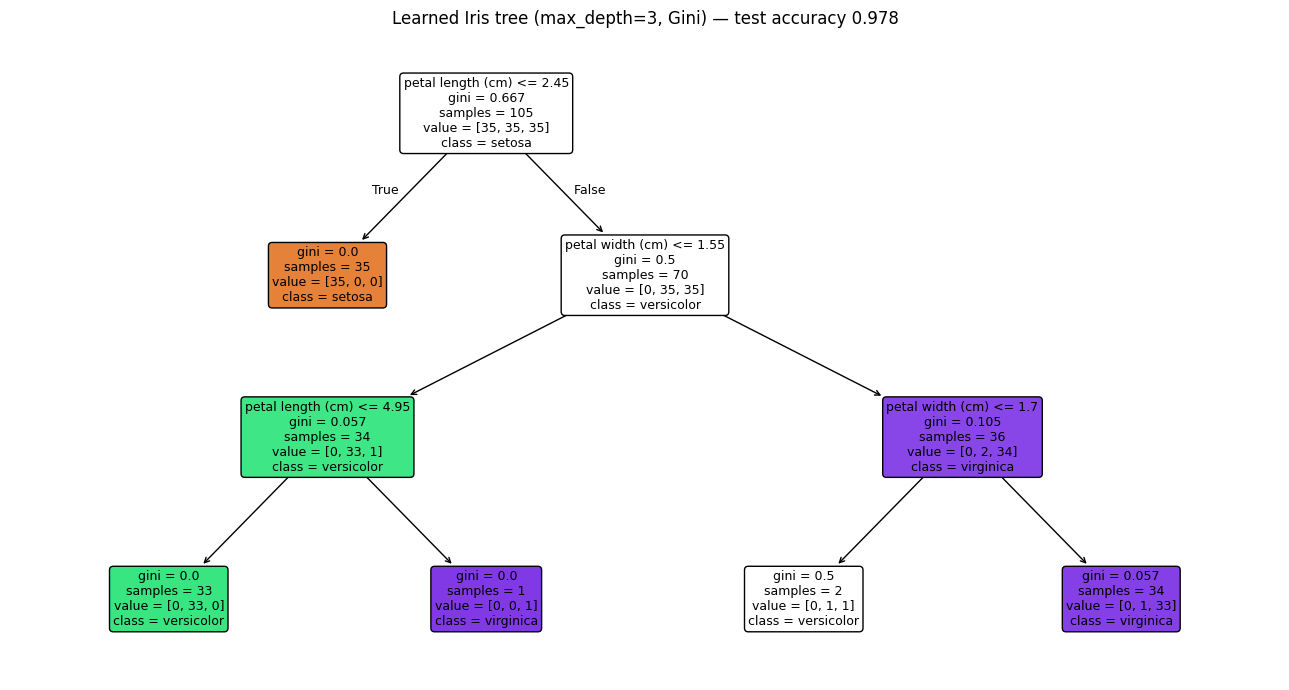

In [7]:
iris_full = load_iris_full()
clf = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42).fit(iris_full.x_train, iris_full.y_train)
fig, ax = plt.subplots(figsize=(13, 7))
plot_tree(clf, feature_names=iris_full.feature_names, class_names=list(iris_full.class_names),
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title(f'Learned Iris tree (max_depth=3, Gini) — test accuracy {clf.score(iris_full.x_test, iris_full.y_test):.3f}')
plt.tight_layout()
plt.show()

## Step 7 — What a tree computes: axis-aligned rectangles

Because every split is `feature <= threshold`, a tree carves the feature space into **axis-aligned rectangles** — one predicted class per box. Paint the prediction of our **from-scratch** tree over a dense grid on the 2-feature Iris slice and the tell-tale **staircase** boundary appears: horizontal and vertical edges only, never a diagonal.

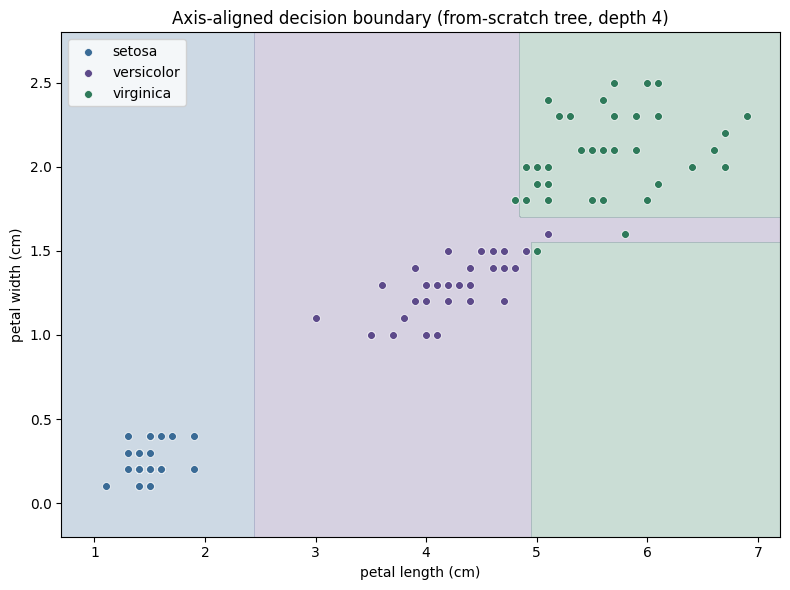

from-scratch <-> scikit-learn agreement at depth 4: 97.8% of test points


In [8]:
tree2d = DecisionTreeScratch(max_depth=4, criterion='gini').fit(iris2d.x_train, iris2d.y_train)
x_all = np.vstack([iris2d.x_train, iris2d.x_test])
x0 = np.linspace(x_all[:,0].min()-0.3, x_all[:,0].max()+0.3, 300)
x1 = np.linspace(x_all[:,1].min()-0.3, x_all[:,1].max()+0.3, 300)
gx, gy = np.meshgrid(x0, x1)
zz = tree2d.predict(np.column_stack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
plt.figure(figsize=(8, 6))
plt.contourf(gx, gy, zz, alpha=0.25, levels=[-0.5,0.5,1.5,2.5], colors=['#3A6B96','#5D4A8A','#2E7A5A'])
for c, colour in enumerate(['#3A6B96','#5D4A8A','#2E7A5A']):
    m = iris2d.y_train == c
    plt.scatter(iris2d.x_train[m,0], iris2d.x_train[m,1], s=32, color=colour,
                edgecolor='white', lw=0.5, label=iris2d.class_names[c])
plt.xlabel(iris2d.feature_names[0])
plt.ylabel(iris2d.feature_names[1])
plt.title('Axis-aligned decision boundary (from-scratch tree, depth 4)')
plt.legend()
plt.tight_layout()
plt.show()

# the boundary above is the from-scratch tree's OWN surface — how close is it to scikit-learn?
agree = verify_against_sklearn(iris2d, max_depth=4).prediction_agreement
print(f'from-scratch <-> scikit-learn agreement at depth 4: {agree*100:.1f}% of test points')

## Step 8 — Why trees overfit: the depth sweep

Keep splitting and a tree eventually isolates every training point in its own pure leaf — 100% training accuracy, but it has **memorized the noise**. On the noisier Breast Cancer data, sweep `max_depth` and watch training accuracy march to 1.0 while **validation** accuracy peaks early and plateaus.

In [9]:
cancer = load_cancer()
sweep = depth_sweep(cancer)
print(f'{"depth":>6}{"train acc":>12}{"val acc":>10}')
for d, tr, va in zip(sweep.depths, sweep.train_acc, sweep.val_acc):
    mark = '   <- best val' if d == sweep.best_depth else ''
    print(f'{d:>6}{tr:>12.3f}{va:>10.3f}{mark}')
print(f'\nbest validation acc {sweep.best_val_acc:.3f} at max_depth={sweep.best_depth}; '
      f'deepest tree memorizes train to {sweep.train_acc[-1]:.3f}.')

 depth   train acc   val acc
     1       0.927     0.912
     2       0.965     0.918
     3       0.980     0.924
     4       0.992     0.924
     5       0.995     0.930   <- best val
     6       1.000     0.918
     8       1.000     0.918
    10       1.000     0.918
    15       1.000     0.918
    20       1.000     0.918

best validation acc 0.930 at max_depth=5; deepest tree memorizes train to 1.000.


## Step 9 — The overfitting curve, plotted

The growing **gap** between the train and validation curves is overfitting made visible. The dashed line marks the depth with the best validation accuracy — the complexity you should actually keep.

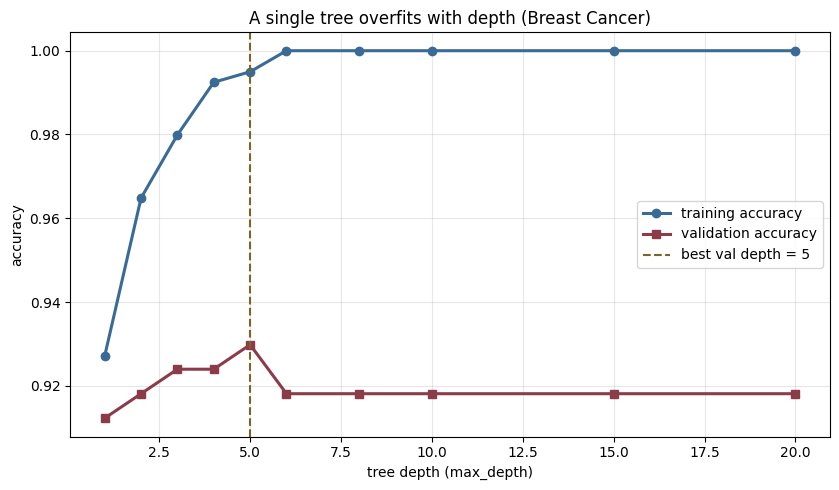

In [10]:
d = np.array(sweep.depths)
plt.figure(figsize=(8.5, 5))
plt.plot(d, sweep.train_acc, 'o-', color='#3A6B96', lw=2.2, label='training accuracy')
plt.plot(d, sweep.val_acc, 's-', color='#8B3B4A', lw=2.2, label='validation accuracy')
plt.axvline(sweep.best_depth, color='#7A6528', ls='--', lw=1.5,
            label=f'best val depth = {sweep.best_depth}')
plt.xlabel('tree depth (max_depth)')
plt.ylabel('accuracy')
plt.title('A single tree overfits with depth (Breast Cancer)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 — Feature importance (mean decrease in impurity)

A tree can tell you **which features mattered**: sum the impurity decrease each feature contributes over every split that used it. This is scikit-learn's `feature_importances_` (MDI). On Breast Cancer, one feature dominates.

In [11]:
imp = feature_importance(cancer)
print('top features by MDI (impurity decrease):')
for name, val in imp.top_features:
    print(f'  {name:<26}{val:.3f}')
print(f'\n{imp.top_features[0][0]!r} alone is {imp.top_features[0][1]*100:.0f}% of the impurity decrease.')

top features by MDI (impurity decrease):
  worst radius              0.727
  worst concave points      0.131
  worst texture             0.050
  texture error             0.031
  worst concavity           0.019
  mean fractal dimension    0.010

np.str_('worst radius') alone is 73% of the impurity decrease.


## Step 11 — The trap: MDI is fooled by high-cardinality features

MDI has a notorious flaw: it is **biased toward features with many distinct values** (they offer more candidate thresholds, so one often lucks into a spurious impurity decrease). Build a controlled case — one weak-but-**real** signal and one **pure-noise, near-unique** column — and watch MDI rank the noise *above* the signal, while **permutation importance** (measured on held-out data) correctly scores it ~0.

In [12]:
print('              MDI (impurity)   permutation (held-out)')
print(f'real signal   {imp.signal_mdi:>13.3f}   {imp.signal_permutation:>18.3f}')
print(f'random_id     {imp.noise_mdi:>13.3f}   {imp.noise_permutation:>18.3f}   <- pure noise!')
print('\nMDI ranks the meaningless near-unique column HIGHER. Never feature-select from raw MDI')
print('when you have high-cardinality features (IDs, timestamps) — use permutation importance or SHAP.')

              MDI (impurity)   permutation (held-out)
real signal           0.176                0.096
random_id             0.824               -0.006   <- pure noise!

MDI ranks the meaningless near-unique column HIGHER. Never feature-select from raw MDI
when you have high-cardinality features (IDs, timestamps) — use permutation importance or SHAP.


## Step 12 — Regression trees: variance reduction and the staircase

The same algorithm does regression: swap Gini for **variance**, and majority-vote for the **mean**. Each leaf predicts the mean target of its interval, so the fit is **piecewise-constant** — a staircase. Fit a shallow and a deep regression tree to one real diabetes feature (`bmi`): the shallow tree captures the trend; the deep tree chases the noise.

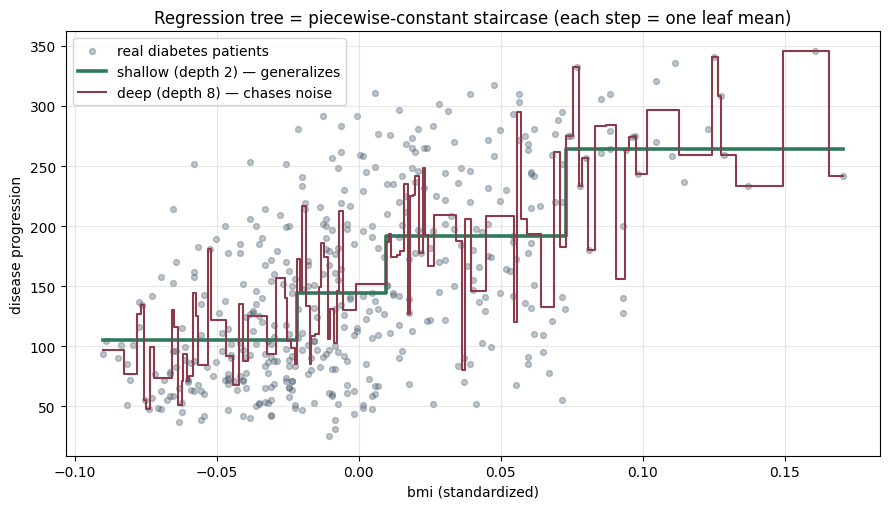

shallow: 4 distinct leaf values | deep: 90 distinct leaf values


In [13]:
reg = regression_staircase()
plt.figure(figsize=(9, 5.2))
plt.scatter(reg.x, reg.y, s=18, color='#4A5B6E', alpha=0.35, label='real diabetes patients')
plt.plot(reg.grid, reg.shallow_pred, drawstyle='steps-mid', color='#2E7A5A', lw=2.6,
         label=f'shallow (depth {reg.shallow_depth}) — generalizes')
plt.plot(reg.grid, reg.deep_pred, drawstyle='steps-mid', color='#8B3B4A', lw=1.5,
         label=f'deep (depth {reg.deep_depth}) — chases noise')
plt.xlabel(f'{reg.feature_name} (standardized)')
plt.ylabel('disease progression')
plt.title('Regression tree = piecewise-constant staircase (each step = one leaf mean)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'shallow: {len(np.unique(reg.shallow_pred))} distinct leaf values | '
      f'deep: {len(np.unique(reg.deep_pred))} distinct leaf values')

## Recap

On real scikit-learn datasets, one runnable notebook built the whole of decision trees:

| Step | What we measured | The takeaway |
|---|---|---|
| 1–2 | Gini/entropy; information gain | 0 when pure, max at 50/50; gain = parent − weighted children |
| 3–4 | best-split search; grow from scratch | greedy `feature <= t?` splits, recursed to a flowchart |
| 5 | verify vs scikit-learn | **same test accuracy**, ~total prediction agreement — genuine CART |
| 6–7 | plot the tree; the boundary | axis-aligned **rectangles** — a staircase, never a diagonal |
| 8–9 | the depth sweep | train → **1.0** while validation plateaus; keep the best-val depth |
| 10–11 | MDI importance; the trap | MDI is **fooled** by a high-cardinality noise column; permutation is not |
| 12 | regression staircase | leaf = **mean**; piecewise-constant; deep overfits, and trees can't extrapolate |

**A decision tree recursively splits the feature space with axis-aligned `feature <= t?` questions, greedily maximizing information gain.** It is low-bias but high-variance — which is exactly why **random forests** (↓ variance) and **gradient boosting** (↓ bias) ensemble trees. The single tree is the on-ramp; the ensembles are the destination.